# BAN7201 Lecture Notebook  
## Dissecting Visual Models with the Telco Customer Churn Dataset

**Course:** BAN7201 Data Visualization  
**Topic:** Dissecting Visual Models  
**Focus:** Gestalt Principles, Preattentive Attributes, and Business Insight


## Lecture Purpose

In this lecture we explore how visualization design affects interpretation.

We will:
1. Start with a business question  
2. Build a **bad visualization**  
3. Diagnose design problems  
4. Improve the chart using **Gestalt principles** and **preattentive attributes**


## Dataset

Telco Customer Churn Dataset

Download from Kaggle:
https://www.kaggle.com/blastchar/telco-customer-churn

Expected file name:

`Telco-Customer-Churn.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

DATA_PATH = "../../data/TelcoCustomerChurn.csv"

df = pd.read_csv(DATA_PATH)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Example 1 — Churn by Contract Type

## Business Question
Which contract types have the highest churn?

We will focus on the column Contract and Churn

In [2]:
churn_contract = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="Churn Rate")
)

churn_contract


,Contract,Churn Rate
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


## Bad Visualization

Problems:
- random colors
- unsorted bars
- no emphasis on high churn


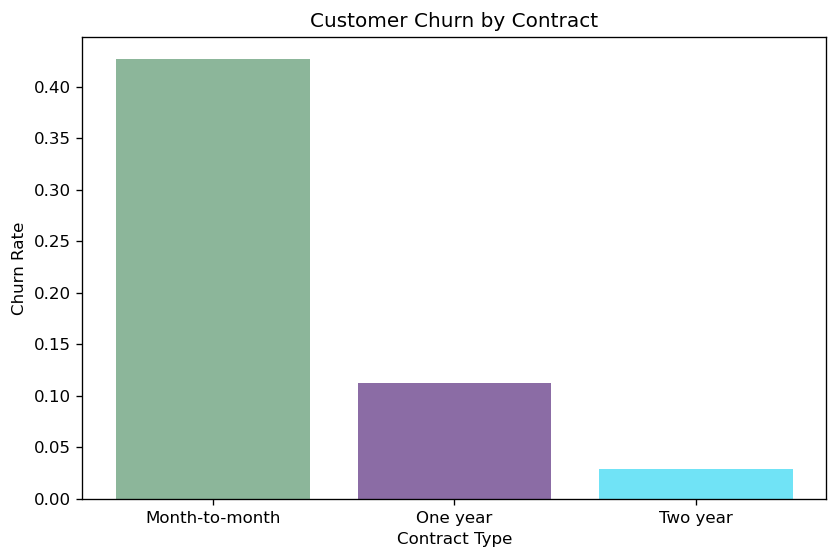

In [3]:
np.random.seed(0)
colors = np.random.rand(len(churn_contract),3)

plt.figure(figsize=(8,5))
plt.bar(churn_contract["Contract"], churn_contract["Churn Rate"], color=colors)
plt.title("Customer Churn by Contract")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()


## Improved Visualization

Design improvements

Gestalt:
- similarity
- figure-ground

Preattentive:
- position
- color


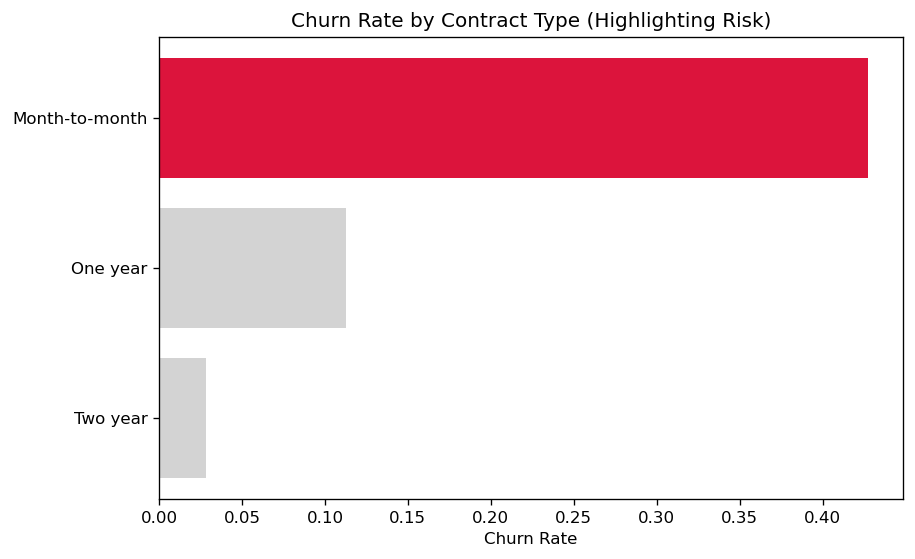

In [4]:
churn_sorted = churn_contract.sort_values("Churn Rate")

colors = ["crimson" if x == churn_sorted["Churn Rate"].max() else "lightgray"
          for x in churn_sorted["Churn Rate"]]

plt.figure(figsize=(8,5))

plt.barh(churn_sorted["Contract"], churn_sorted["Churn Rate"], color=colors)

plt.xlabel("Churn Rate")
plt.title("Churn Rate by Contract Type (Highlighting Risk)")

plt.show()


# Example 2 — Monthly Charges vs Tenure

## Business Question
Do customers with higher monthly charges churn earlier?


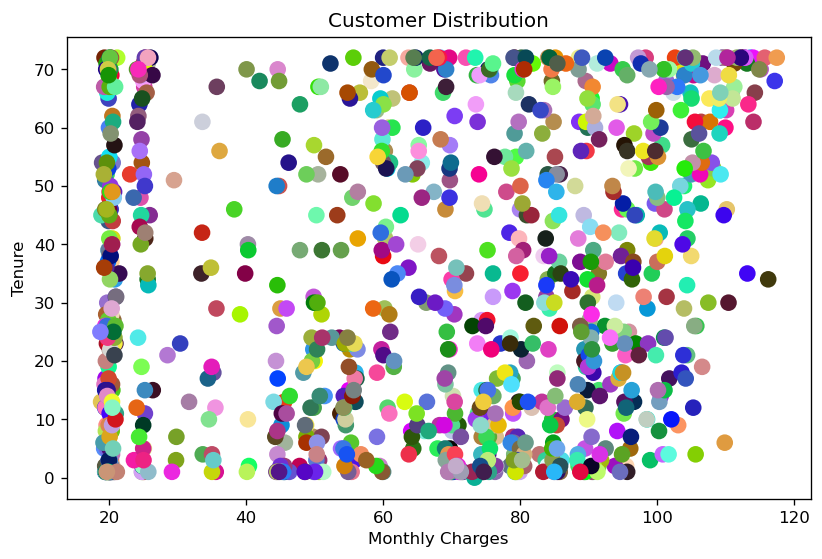

In [5]:
sample = df.sample(min(1000,len(df)), random_state=42)

np.random.seed(1)
colors = np.random.rand(len(sample),3)

plt.figure(figsize=(8,5))
plt.scatter(sample["MonthlyCharges"], sample["tenure"], c=colors, s=80)

plt.xlabel("Monthly Charges")
plt.ylabel("Tenure")
plt.title("Customer Distribution")
plt.show()


## Improved Visualization
Use color to represent churn status.


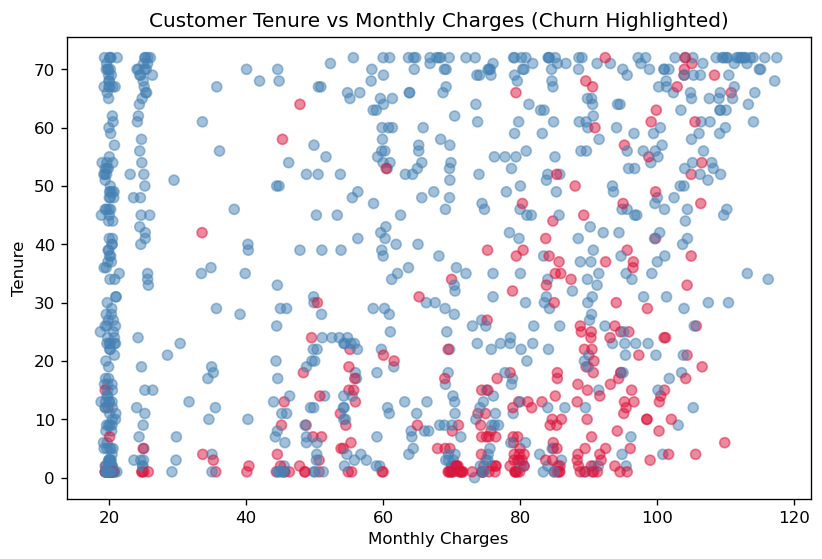

In [6]:
sample = df.sample(min(1000,len(df)), random_state=42)

colors = sample["Churn"].map({"Yes":"crimson","No":"steelblue"})

plt.figure(figsize=(8,5))
plt.scatter(sample["MonthlyCharges"], sample["tenure"],
            c=colors, alpha=0.5)

plt.xlabel("Monthly Charges")
plt.ylabel("Tenure")
plt.title("Customer Tenure vs Monthly Charges (Churn Highlighted)")
plt.show()


# Example 3 — Payment Method Distribution

## Business Question
Which payment method is the most common one?

Why a Pie Chart Is Appropriate for This Question

We can use a pie chart to examine the distribution of payment methods because:

1. The number of categories is limited.

    Pie charts work best when there are only a few categories. Too many slices can make the chart difficult to interpret.

2. The category proportions are relatively balanced.

    When no single category dominates the data, each slice occupies a visible portion of the chart, making comparisons easier.

3. Key slices can be highlighted using visual emphasis.

    Features such as an exploded slice can draw the reader’s attention to the most important category.

4. The chart communicates both ranking and proportions.

    A pie chart allows the reader to quickly identify the largest and smallest categories while also showing the percentage share of each payment method.

In [7]:
payment_counts = df["PaymentMethod"].value_counts().reset_index()
payment_counts.columns = ["Payment Method","Customers"]

payment_counts


,Payment Method,Customers
0,Electronic check,2365
1,Mailed check,1612
2,Bank transfer (automatic),1544
3,Credit card (automatic),1522


## Bad Visualization

Pie charts make comparison difficult.


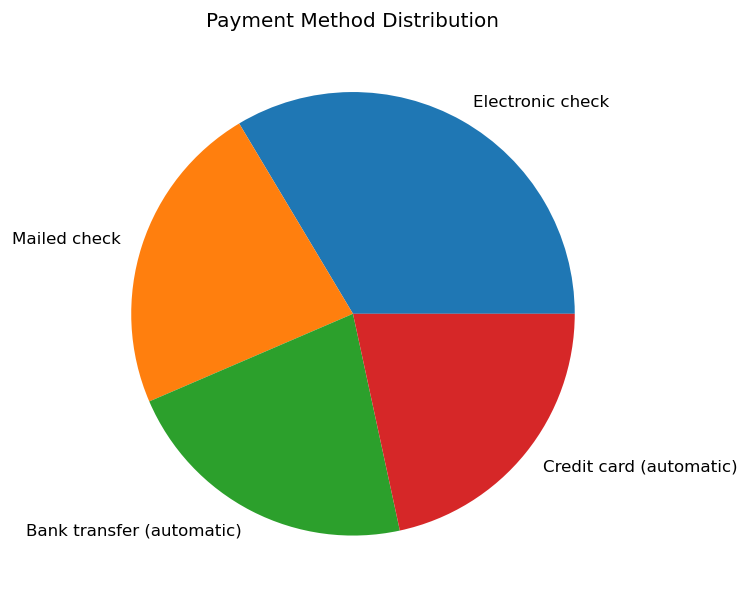

In [8]:
plt.figure(figsize=(6,6))
plt.pie(payment_counts["Customers"], labels=payment_counts["Payment Method"])
plt.title("Payment Method Distribution")
plt.show()


## Improved Visualization
Use bar charts for easier comparison.


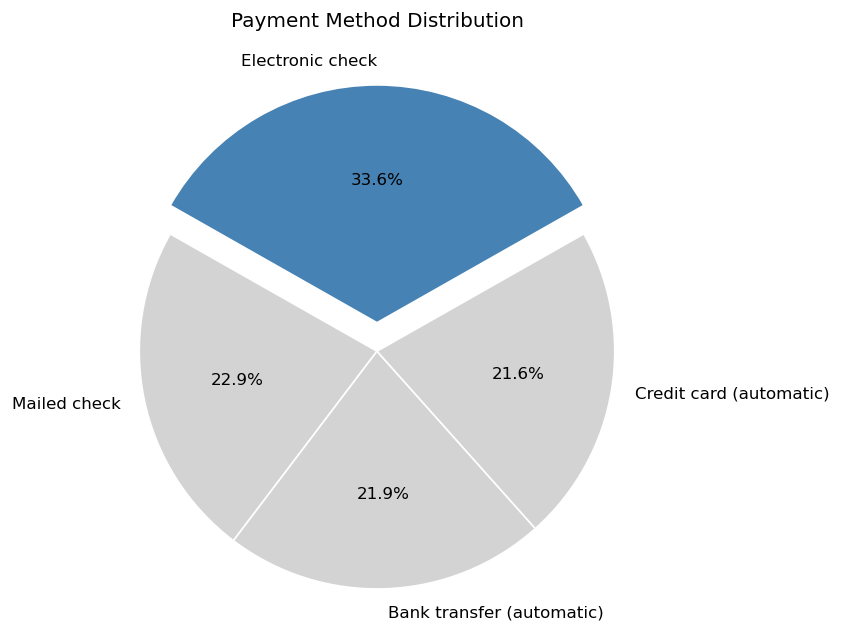

In [13]:
payment_counts = df["PaymentMethod"].value_counts()

labels = payment_counts.index
sizes = payment_counts.values

# Identify largest slice
largest_idx = sizes.argmax()

# Explode only the largest slice
explode = [0.12 if i == largest_idx else 0 for i in range(len(sizes))]

# Use one strong color for the largest slice and muted colors for the others
colors = ["lightgray"] * len(sizes)
colors[largest_idx] = "steelblue"

# Compute start angle so the largest slice is centered at the top (90 degrees)
largest_angle = 360 * sizes[largest_idx] / sizes.sum()
startangle = 90 - largest_angle / 2

plt.figure(figsize=(6, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=startangle,
    explode=explode,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 10}
)

plt.title("Payment Method Distribution", pad=20)
plt.axis("equal")
plt.show()

### If this document is a project report that will be reviewed by your supervisor, any idea that you want to make it even better?

# Key Takeaways

Thinking like a designer:
- highlights important information
- reduces cognitive load
- supports decision making
